Conexão OK!
Engine SQLAlchemy OK!
Total de partidas: 38


/tmp/ipykernel_13711/2990254500.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


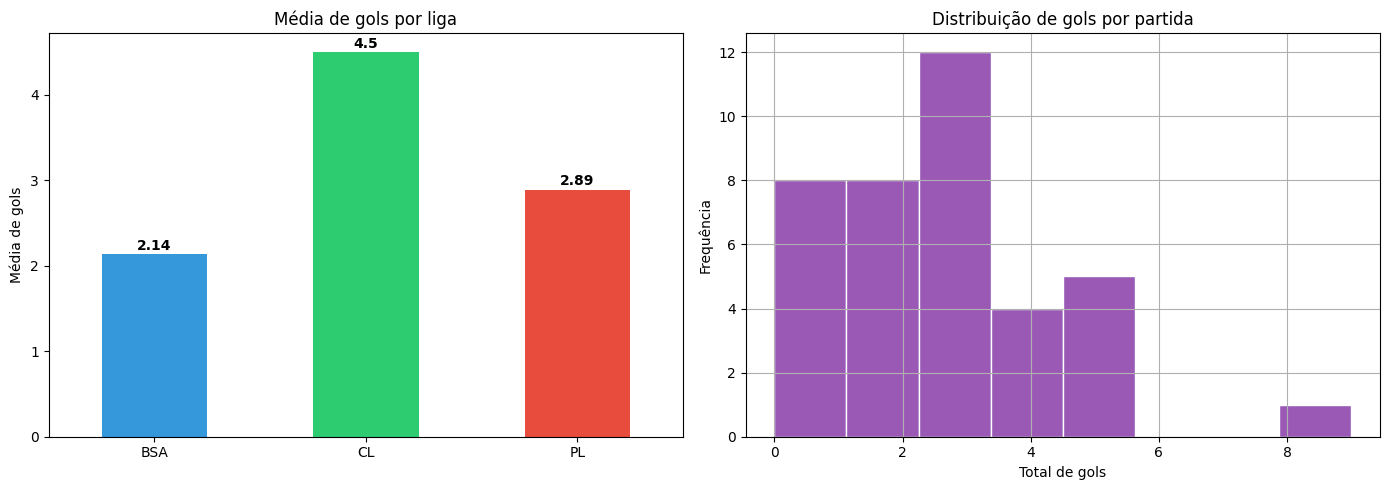

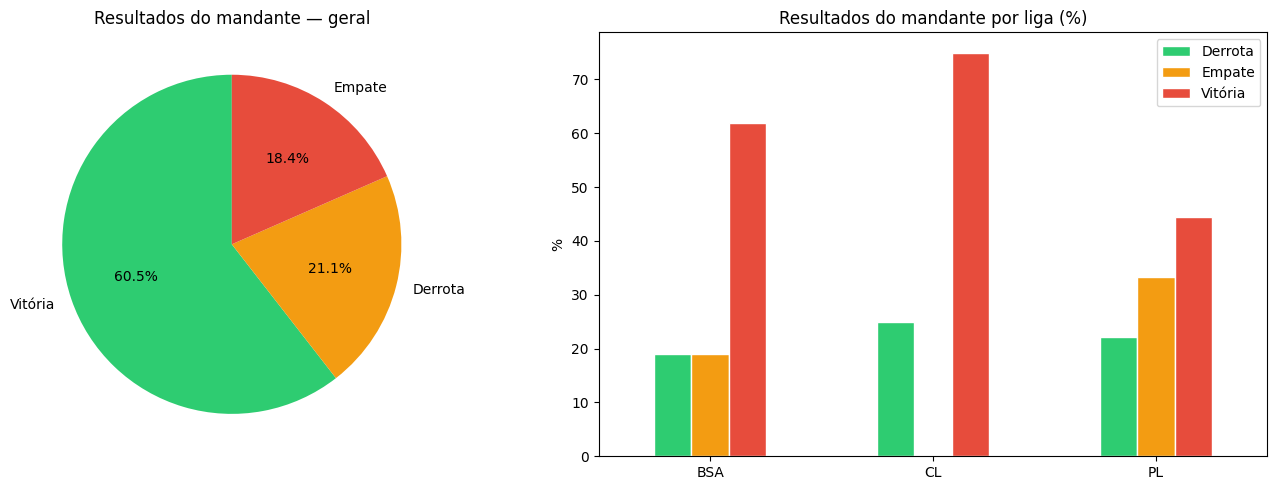

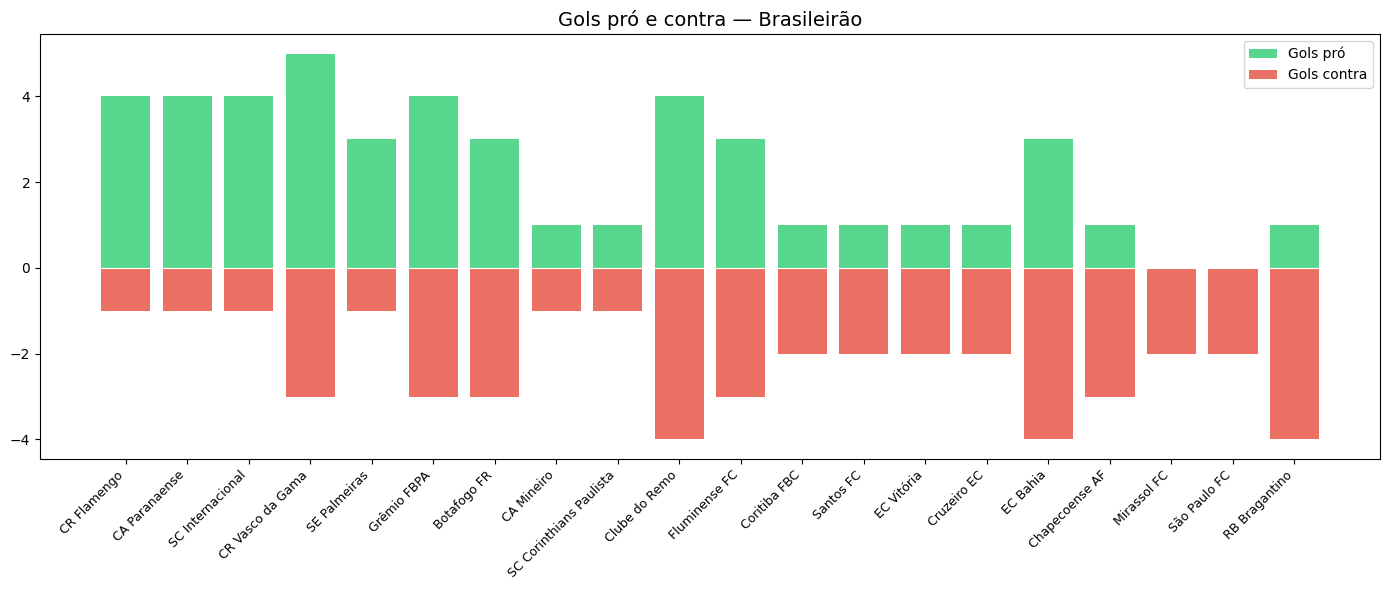

INSIGHTS — ANÁLISE EXPLORATÓRIA

Total de partidas analisadas: 38
Período: 16/03/2026 a 22/03/2026

Média de gols por liga:
  BSA: 2.14 gols/partida
  CL: 4.50 gols/partida
  PL: 2.89 gols/partida

Vantagem do mandante (geral):
  Vitória: 60.5%
  Derrota: 21.1%
  Empate: 18.4%

Jogo com mais gols:
  FC Barcelona 7 x 2 Newcastle United FC (CL)


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from dotenv import load_dotenv
from sqlalchemy import create_engine
import os

load_dotenv('/home/larbac0/football-analytics/.env')

engine = psycopg2.connect(
    host=os.getenv("DB_HOST"),
    port=os.getenv("DB_PORT"),
    dbname=os.getenv("DB_NAME"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD")
)
engine.set_client_encoding('UTF8')
print("Conexão OK!")

DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
print("Engine SQLAlchemy OK!")

df = pd.read_sql("""
    SELECT 
        m.id,
        m.competition_code,
        m.match_date,
        m.status,
        ht.name AS home_team,
        at.name AS away_team,
        m.home_score,
        m.away_score,
        m.stage
    FROM silver.matches m
    JOIN silver.teams ht ON ht.id = m.home_team_id
    JOIN silver.teams at ON at.id = m.away_team_id
    WHERE m.status = 'FINISHED'
    ORDER BY m.match_date DESC
""", conn)

df['match_date'] = pd.to_datetime(df['match_date'])
df['total_gols'] = df['home_score'] + df['away_score']
df['dia_semana'] = df['match_date'].dt.day_name()

print(f"Total de partidas: {len(df)}")
df.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Média de gols por liga
media_gols = df.groupby('competition_code')['total_gols'].mean().round(2)
media_gols.plot(kind='bar', ax=axes[0], color=['#3498db','#2ecc71','#e74c3c'])
axes[0].set_title('Média de gols por liga')
axes[0].set_xlabel('')
axes[0].set_ylabel('Média de gols')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(media_gols):
    axes[0].text(i, v + 0.05, str(v), ha='center', fontweight='bold')

# Distribuição total de gols
df['total_gols'].hist(ax=axes[1], bins=8, color='#9b59b6', edgecolor='white')
axes[1].set_title('Distribuição de gols por partida')
axes[1].set_xlabel('Total de gols')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

df['resultado_mandante'] = df.apply(lambda r:
    'Vitória'  if r['home_score'] > r['away_score'] else
    'Empate'   if r['home_score'] == r['away_score'] else
    'Derrota', axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Geral
contagem = df['resultado_mandante'].value_counts()
cores = ['#2ecc71','#f39c12','#e74c3c']
contagem.plot(kind='pie', ax=axes[0], colors=cores,
              autopct='%1.1f%%', startangle=90)
axes[0].set_title('Resultados do mandante — geral')
axes[0].set_ylabel('')

# Por liga
cross = pd.crosstab(df['competition_code'], df['resultado_mandante'], normalize='index') * 100
cross.plot(kind='bar', ax=axes[1], color=cores, edgecolor='white')
axes[1].set_title('Resultados do mandante por liga (%)')
axes[1].set_xlabel('')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

bsa = df[df['competition_code'] == 'BSA'].copy()

# Gols marcados + sofridos por time (mandante)
mandante = bsa.groupby('home_team').agg(
    gols_pro=('home_score','sum'),
    gols_contra=('away_score','sum'),
    jogos=('id','count')
).reset_index().rename(columns={'home_team':'team'})

visitante = bsa.groupby('away_team').agg(
    gols_pro=('away_score','sum'),
    gols_contra=('home_score','sum'),
    jogos=('id','count')
).reset_index().rename(columns={'away_team':'team'})

totais = pd.concat([mandante, visitante]).groupby('team').sum().reset_index()
totais['saldo'] = totais['gols_pro'] - totais['gols_contra']
totais = totais.sort_values('saldo', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(totais))
ax.bar(x, totais['gols_pro'], label='Gols pró', color='#2ecc71', alpha=0.8)
ax.bar(x, -totais['gols_contra'], label='Gols contra', color='#e74c3c', alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(totais['team'], rotation=45, ha='right', fontsize=9)
ax.axhline(0, color='white', linewidth=0.8)
ax.set_title('Gols pró e contra — Brasileirão', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

print("=" * 50)
print("INSIGHTS — ANÁLISE EXPLORATÓRIA")
print("=" * 50)

print(f"\nTotal de partidas analisadas: {len(df)}")
print(f"Período: {df['match_date'].min().strftime('%d/%m/%Y')} a {df['match_date'].max().strftime('%d/%m/%Y')}")

print("\nMédia de gols por liga:")
for liga, media in df.groupby('competition_code')['total_gols'].mean().items():
    print(f"  {liga}: {media:.2f} gols/partida")

print(f"\nVantagem do mandante (geral):")
vc = df['resultado_mandante'].value_counts(normalize=True) * 100
for res, pct in vc.items():
    print(f"  {res}: {pct:.1f}%")

print(f"\nJogo com mais gols:")
top = df.loc[df['total_gols'].idxmax()]
print(f"  {top['home_team']} {top['home_score']} x {top['away_score']} {top['away_team']} ({top['competition_code']})")